In [1]:
import pandas as pd


In [22]:
root="/home/mcn26/project_pi_skr2/shared/tabula_data/simulated/shendure_pow_analysis/sim_with_orthos_20251206/results/spread_hypothesis_20251119/wald"

df=pd.read_csv(f"{root}/0",sep="\t")
df

,comparison_CRE,reference_CRE,comparison_cell_type,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,wald_debug,test_type,bh_p
0,inactive_0,reference,Cardiomyocytes,Cardiomyocytes,NaN,NaN,NaN,NaN,False,no contrast term for inactive_0,wald,1.000000
1,inactive_0,reference,EpiblastPrimitiveStreak,EpiblastPrimitiveStreak,NaN,-0.911781,0.361884,0.709590,False,ok,wald,0.950508
2,inactive_0,reference,ExEndodermParietal,ExEndodermParietal,NaN,0.869431,0.384612,1.264329,False,ok,wald,0.951218
3,inactive_0,reference,ExEndodermVisceral,ExEndodermVisceral,NaN,0.403675,0.686452,1.135264,False,ok,wald,1.000000
4,inactive_0,reference,Haematoendothelial,Haematoendothelial,NaN,NaN,NaN,NaN,False,no contrast term for inactive_0,wald,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
5495,active_45,active_45,reference,SurfaceEctoderm,NaN,0.000000,1.000000,1.000000,False,ok,wald,1.000000
5496,active_46,active_46,reference,SurfaceEctoderm,NaN,0.000000,1.000000,1.000000,False,ok,wald,1.000000
5497,active_47,active_47,reference,SurfaceEctoderm,NaN,0.000000,1.000000,1.000000,False,ok,wald,1.000000
5498,active_48,active_48,reference,SurfaceEctoderm,NaN,0.000000,1.000000,1.000000,False,ok,wald,1.000000


In [23]:
truth=pd.read_csv("/home/mcn26/project_pi_skr2/shared/tabula_data/simulated/shendure_pow_analysis/spread_gt_20251119.tsv",sep="\t",index_col=0)
truth

,cell_type,true_mean,cre_id
0,Cardiomyocytes,0.019350,reference
1,EpiblastPrimitiveStreak,0.019350,reference
2,ExEndodermParietal,0.019350,reference
3,ExEndodermVisceral,0.019350,reference
4,Haematoendothelial,0.019350,reference
...,...,...,...
49,Mesoderm,111.241567,active_49
49,NeuroectodermBrain,111.241567,active_49
49,NeuroectodermRostral,111.241567,active_49
49,SurfaceEctoderm,111.241567,active_49


In [24]:
import numpy as np

In [25]:
import pandas as pd
import numpy as np

# --- 1. Build lookup for true means ---

truth_index = truth.set_index(['cell_type', 'cre_id'])['true_mean']

idx_ref = pd.MultiIndex.from_frame(df[['reference_cell_type', 'reference_CRE']])
idx_cmp = pd.MultiIndex.from_frame(df[['comparison_cell_type', 'comparison_CRE']])

df['true_reference_mean']  = truth_index.reindex(idx_ref).to_numpy()
df['true_comparison_mean'] = truth_index.reindex(idx_cmp).to_numpy()

# --- 2. Compute difference ---
df['true_mean_difference'] = df['true_comparison_mean'] - df['true_reference_mean']

# --- 3. Categorize into zero vs different ---
eps = 1e-8
df['true_diff_cat'] = np.where(
    df['true_mean_difference'].abs() < eps,
    'zero',
    'different'
)

# --- 4. Categorize significance ---
df['sig_cat'] = np.where(df['bh_p'] < 0.05, 'sig', 'nonsig')

# --- 5. Crosstab ---
ct = pd.crosstab(df['true_diff_cat'], df['sig_cat'])
print(ct)

# --- 6. Extract TP / FP / TN / FN ---

TP = ct.loc['different', 'sig']      if ('different' in ct.index and 'sig' in ct.columns) else 0
FP = ct.loc['zero', 'sig']           if ('zero' in ct.index and 'sig' in ct.columns) else 0
TN = ct.loc['zero', 'nonsig']        if ('zero' in ct.index and 'nonsig' in ct.columns) else 0
FN = ct.loc['different', 'nonsig']   if ('different' in ct.index and 'nonsig' in ct.columns) else 0

print("\nConfusion matrix counts:")
print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"TN: {TN}")
print(f"FN: {FN}")


sig_cat        nonsig  sig
true_diff_cat             
different         127  532
zero             4781   60

Confusion matrix counts:
TP: 532
FP: 60
TN: 4781
FN: 127


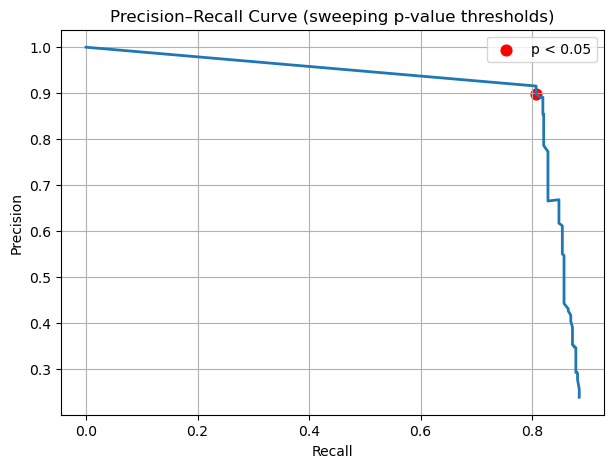

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# --- Encode truth labels ---
y_true = (df['true_diff_cat'] == 'different').astype(int)  # 1 = positive

# --- Sweep thresholds ---
cutoffs = np.linspace(0, 1, 500)

precisions = []
recalls = []

for c in cutoffs:
    y_pred = (df['bh_p'] < c).astype(int)

    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))

    precision = TP / (TP + FP) if TP + FP > 0 else 1.0
    recall    = TP / (TP + FN) if TP + FN > 0 else 0.0

    precisions.append(precision)
    recalls.append(recall)

# --- Plot PR curve ---
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (sweeping p-value thresholds)")
plt.grid(True)

p_cut = 0.05
y_pred_05 = (df['bh_p'] < p_cut).astype(int)

TP = np.sum((y_pred_05 == 1) & (y_true == 1))
FP = np.sum((y_pred_05 == 1) & (y_true == 0))
FN = np.sum((y_pred_05 == 0) & (y_true == 1))

prec_05 = TP / (TP + FP) if TP + FP > 0 else 1
rec_05  = TP / (TP + FN) if TP + FN > 0 else 0

plt.scatter([rec_05], [prec_05], color="red", s=60, label="p < 0.05")
plt.legend()
plt.show()


plt.show()


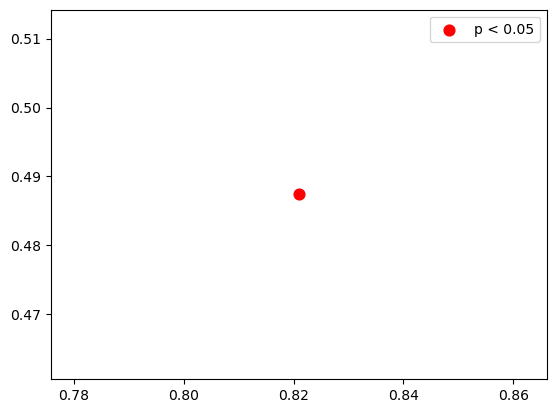

In [20]:
p_cut = 0.05
y_pred_05 = (df['bh_p'] < p_cut).astype(int)

TP = np.sum((y_pred_05 == 1) & (y_true == 1))
FP = np.sum((y_pred_05 == 1) & (y_true == 0))
FN = np.sum((y_pred_05 == 0) & (y_true == 1))

prec_05 = TP / (TP + FP) if TP + FP > 0 else 1
rec_05  = TP / (TP + FN) if TP + FN > 0 else 0

plt.scatter([rec_05], [prec_05], color="red", s=60, label="p < 0.05")
plt.legend()
plt.show()


In [3]:
import scMPRAforge as scm

2025-12-07 22:02:14.588013: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-07 22:02:14.591560: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/software/2024a/software/code-server/4.103.0/lib:/apps/software/2024a/software/gettext/0.22.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libiconv/1.17-GCCcore-13.3.0/lib:/apps/software/2024a/software/ncurses/6.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/apps/software/2024a/software/XZ/5.4.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/expat/2.6.2-GCCcore-13.3.0/lib:/apps/software/2024a/software/cUR

In [10]:
x=scm.scMPRA_data.from_parquet("/home/mcn26/project_pi_skr2/shared/tabula_data/simulated/shendure_pow_analysis/sim_with_orthos_20251119/scMPRA/0.scmpra")

In [16]:
import numpy as np

In [24]:
df=x.data
in_0=np.mean(df[df["cre_id"]=="inactive_0"][df["cell_type"]=="EpiblastPrimitiveStreak"]["umis_mpra_bc"])
in_0

0.026501766784452298

In [25]:
ref=np.mean(df[df["cre_id"]=="reference"][df["cell_type"]=="EpiblastPrimitiveStreak"]["umis_mpra_bc"])
ref

0.017586912065439674

In [27]:
ref/in_0

0.663612815269257